In [ ]:
import pandas as pd
import gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Data

In [ ]:
import glob

train_folder_path = "/kaggle/input/dtsett/data/2025/train"
test_folder_path = "/kaggle/input/dtsett/data/2025/test"

train_files = glob.glob(train_folder_path + "*.parquet")
if len(train_files) == 0:
    print("No .parquet files found in train folder. Checking for other extensions...")
    train_files = glob.glob(train_folder_path + "*")
    print("Files found:", train_files)

df_train = pd.concat([pd.read_parquet(file) for file in train_files])

print("Training Data Shape:", df_train.shape)
print("\nTraining Data Preview:")
print(df_train.head())

No .parquet files found in train folder. Checking for other extensions...
Files found: ['/kaggle/input/dtsett/data/2025/train']
Training Data Shape: (229624, 23)

Training Data Preview:
   product_id                                              title  \
0   699437355  Children&#39;s circle skirt BLUE GALAXY made o...   
1  1323699538  Cow Birthday Tutu for kids, Farm Theme Bday Ou...   
2  1142910558  Zebra print tutu, animal print Skirt, World bo...   
3  1320296928  Lilac Tutu Rainbow Dots // Girl&#39;s Tutu, Tu...   
4   854901795  Bumblebee tutu yellow and black tutu halloween...   

                                         description  \
0  The fuxandfriends children&#39;s full circle s...   
1  💄This listing is for the TUTU ONLY (double rib...   
2  All tutus are handmade to order with two layer...   
3  Step aside because the princess pop star is he...   
4  Sparkle, shimmer, twirl and spin,\nThis tutu&#...   

                                                tags      type room 

## Preprocessing

In [ ]:
# Check for missing values
print("Missing Values in Each Column:")
print(df_train.isnull().sum())

# Distribution of top_category_id
print("Top Category ID Distribution:")
print(df_train['top_category_text'].value_counts())

# Distribution of bottom_category_id
print("\nBottom Category ID Distribution:")
print(df_train['bottom_category_text'].value_counts())

Missing Values in Each Column:
product_id              0
title                   0
description             0
tags                    0
type                    0
room                    0
craft_type              0
recipient               0
material                0
occasion                0
holiday                 0
art_subject             0
style                   0
shape                   0
pattern                 0
bottom_category_id      0
bottom_category_text    0
top_category_id         0
top_category_text       0
primary_color_id        0
primary_color_text      0
secondary_color_id      0
secondary_color_text    0
dtype: int64
Top Category ID Distribution:
top_category_text
home_and_living                54600
craft_supplies_and_tools       33393
clothing                       30143
toys_and_games                 13835
accessories                    12416
paper_and_party_supplies       12207
bath_and_beauty                11327
weddings                       10143
shoes         

In [ ]:
def count_empty_cells(df):
    empty_counts = {}
    for col in df.columns:
        if df[col].dtype == 'object':
            empty_counts[col] = ((df[col] == "") | (df[col].str.strip() == "")).sum()
    return pd.Series(empty_counts)

empty_cell_counts = count_empty_cells(df_train)
print("Empty Cells in Each Column:")
print(empty_cell_counts)

Empty Cells in Each Column:
title                      810
description                810
tags                     31169
type                       348
room                    220686
craft_type              201862
recipient               218815
material                209384
occasion                171550
holiday                 183359
art_subject             226885
style                   213730
shape                   227137
pattern                 218042
bottom_category_text         0
top_category_text            0
primary_color_text           0
secondary_color_text         0
dtype: int64


In [ ]:
df_train['title_length'] = df_train['title'].apply(lambda x: len(str(x).split()))
df_train['description_length'] = df_train['description'].apply(lambda x: len(str(x).split()))
df_train['tags_length'] = df_train['tags'].apply(lambda x: len(str(x).split(',')))

print("Summary Statistics of Text Lengths:")
print(df_train[['title_length', 'description_length', 'tags_length']].describe())

print("\nSample Titles:")
print(df_train['title'].head())

print("\nSample Descriptions:")
print(df_train['description'].head())

print("\nSample Tags:")
print(df_train['tags'].head())

Summary Statistics of Text Lengths:
        title_length  description_length    tags_length
count  229624.000000       229624.000000  229624.000000
mean       14.613150          178.663959      10.424006
std         6.374611          194.245363       4.359984
min         0.000000            0.000000       1.000000
25%         9.000000           68.000000      10.000000
50%        15.000000          131.000000      13.000000
75%        20.000000          231.000000      13.000000
max        39.000000        10287.000000      13.000000

Sample Titles:
0    Children&#39;s circle skirt BLUE GALAXY made o...
1    Cow Birthday Tutu for kids, Farm Theme Bday Ou...
2    Zebra print tutu, animal print Skirt, World bo...
3    Lilac Tutu Rainbow Dots // Girl&#39;s Tutu, Tu...
4    Bumblebee tutu yellow and black tutu halloween...
Name: title, dtype: object

Sample Descriptions:
0    The fuxandfriends children&#39;s full circle s...
1    💄This listing is for the TUTU ONLY (double rib...
2    All t

In [ ]:
categorical_features = ['room', 'craft_type', 'recipient', 'material', 'occasion', 'holiday',
                        'art_subject', 'style', 'shape', 'pattern', 'primary_color_text', 'secondary_color_text']

for feature in categorical_features:
    print(f"\nUnique Values in {feature}:")
    print(df_train[feature].unique())


Unique Values in room:
['' 'kitchen & dining' 'entryway' 'craft' 'living room' 'bedroom' 'dorm'
 'nursery' 'bathroom' 'office' 'patio & outdoor' 'kids' 'man cave'
 'game room' 'bar' 'porch' 'garage' 'laundry' 'yard']

Unique Values in craft_type:
['' 'photography' 'party & gifting' 'home improvement' 'leatherworking'
 'upholstery' 'model making' 'carving & whittling' 'bookbinding'
 'dollhouses & miniatures' 'calligraphy' 'painting'
 'printing & printmaking' 'collage' "kids' crafts" 'ceramics & pottery'
 'neon art' 'card making & stationery' 'woodworking & carpentry'
 'scrapbooking' 'nail art' 'doll making' 'enameling' 'mosaic making'
 'baking' 'sewing' 'soap making & bath' 'candy making' 'candle making'
 'canning & preserving' 'quilting' 'cross stitch' 'beading'
 'hat making & hair crafts' 'embroidery' 'needlepoint' 'jewelry making'
 'gardening' 'stained glass' 'drawing & drafting' 'framing' 'origami'
 'coloring' '3d printing' 'electronics & circuitry' 'glass fusing'
 'molding & casti

In [ ]:
import numpy as np

df_train = df_train.replace(r'^\s*$', np.nan, regex=True)

print("Missing Values After Handling Empty Cells:")
print(df_train.isnull().sum())

Missing Values After Handling Empty Cells:
product_id                   0
title                      810
description                810
tags                     31169
type                       348
room                    220686
craft_type              201862
recipient               218815
material                209384
occasion                171550
holiday                 183359
art_subject             226885
style                   213730
shape                   227137
pattern                 218042
bottom_category_id           0
bottom_category_text         0
top_category_id              0
top_category_text            0
primary_color_id             0
primary_color_text           0
secondary_color_id           0
secondary_color_text         0
title_length                 0
description_length           0
tags_length                  0
dtype: int64


In [ ]:
df_train['description'] = df_train['description'].apply(lambda x: ' '.join(str(x).split()[:1000]))

df_train['description_length'] = df_train['description'].apply(lambda x: len(str(x).split()))

print("New Maximum Description Length:", df_train['description_length'].max())

New Maximum Description Length: 1000


In [ ]:
df_train = df_train[df_train['description'].apply(lambda x: isinstance(x, str) and len(x.split()) >= 5)]

print("Dataset Shape After Dropping Noisy Rows:", df_train.shape)

Dataset Shape After Dropping Noisy Rows: (228061, 26)


In [ ]:
print("Missing Values After Cleaning Descriptions:")
print(df_train.isnull().sum())

Missing Values After Cleaning Descriptions:
product_id                   0
title                        0
description                  0
tags                     30060
type                       345
room                    219186
craft_type              200465
recipient               217287
material                207911
occasion                170416
holiday                 182106
art_subject             225348
style                   212181
shape                   225582
pattern                 216556
bottom_category_id           0
bottom_category_text         0
top_category_id              0
top_category_text            0
primary_color_id             0
primary_color_text           0
secondary_color_id           0
secondary_color_text         0
title_length                 0
description_length           0
tags_length                  0
dtype: int64


In [ ]:
df_train['tags'] = df_train['tags'].fillna("No Tags")

df_train['tags_length'] = df_train['tags'].apply(lambda x: len(str(x).split(',')))

print("Summary Statistics of Tag Lengths After Imputation:")
print(df_train['tags_length'].describe())

Summary Statistics of Tag Lengths After Imputation:
count    228061.000000
mean         10.472948
std           4.320725
min           1.000000
25%          10.000000
50%          13.000000
75%          13.000000
max          13.000000
Name: tags_length, dtype: float64


In [ ]:
categorical_features = ['room', 'craft_type', 'recipient', 'material', 'occasion',
                        'holiday', 'art_subject', 'style', 'shape', 'pattern']

missing_proportions = df_train[categorical_features].isnull().mean()
print("Proportion of Missing Values in Categorical Features:")
print(missing_proportions.sort_values(ascending=False))

Proportion of Missing Values in Categorical Features:
shape          0.989130
art_subject    0.988104
room           0.961085
recipient      0.952758
pattern        0.949553
style          0.930370
material       0.911646
craft_type     0.878997
holiday        0.798497
occasion       0.747239
dtype: float64


In [ ]:
high_missing_features = ['shape', 'art_subject', 'room', 'recipient', 'pattern', 'style']

df_train = df_train.drop(columns=high_missing_features)

print("Remaining Columns After Dropping Highly Missing Features:")
print(df_train.columns)

Remaining Columns After Dropping Highly Missing Features:
Index(['product_id', 'title', 'description', 'tags', 'type', 'craft_type',
       'material', 'occasion', 'holiday', 'bottom_category_id',
       'bottom_category_text', 'top_category_id', 'top_category_text',
       'primary_color_id', 'primary_color_text', 'secondary_color_id',
       'secondary_color_text', 'title_length', 'description_length',
       'tags_length'],
      dtype='object')


In [ ]:
moderately_missing_features = ['material', 'craft_type', 'holiday', 'occasion']


for feature in moderately_missing_features:
    df_train[feature] = df_train[feature].fillna("Unknown")

print("Missing Values After Imputation:")
print(df_train.isnull().sum())

Missing Values After Imputation:
product_id                0
title                     0
description               0
tags                      0
type                    345
craft_type                0
material                  0
occasion                  0
holiday                   0
bottom_category_id        0
bottom_category_text      0
top_category_id           0
top_category_text         0
primary_color_id          0
primary_color_text        0
secondary_color_id        0
secondary_color_text      0
title_length              0
description_length        0
tags_length               0
dtype: int64


## Visualizations

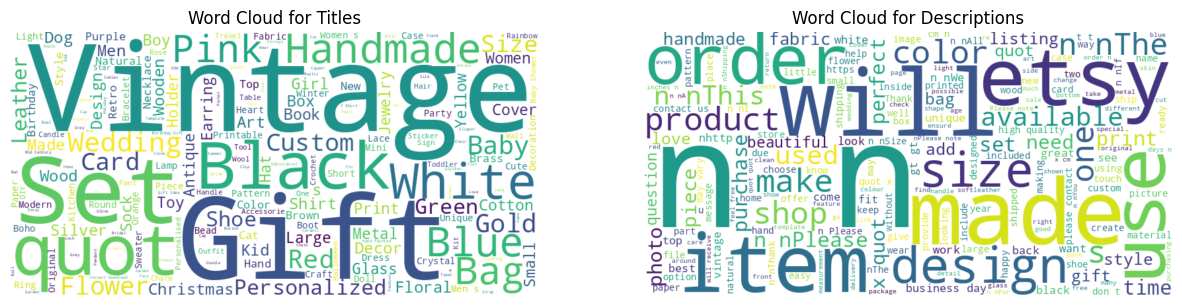

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df_sample = df_train.sample(n=10000, random_state=42)

all_titles = " ".join(df_sample['title'].dropna())
all_descriptions = " ".join(df_sample['description'].dropna())

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
wordcloud_titles = WordCloud(background_color='white', width=800, height=400).generate(all_titles)
plt.imshow(wordcloud_titles, interpolation='bilinear')
plt.title("Word Cloud for Titles")
plt.axis('off')

plt.subplot(1, 2, 2)
wordcloud_descriptions = WordCloud(background_color='white', width=800, height=400).generate(all_descriptions)
plt.imshow(wordcloud_descriptions, interpolation='bilinear')
plt.title("Word Cloud for Descriptions")
plt.axis('off')

plt.show()

In [ ]:
from collections import Counter

all_tags = [tag.strip() for tags in df_train['tags'] for tag in str(tags).split(',')]
tag_counts = Counter(all_tags)

print("Top 20 Most Frequent Tags:")
for tag, count in tag_counts.most_common(20):
    print(f"{tag}: {count}")

Top 20 Most Frequent Tags:
No Tags: 30060
vintage: 5285
handmade: 3848
gift: 3690
gift for her: 2964
Vintage: 2624
home decor: 2268
blue: 1806
white: 1749
Handmade: 1650
pink: 1623
black: 1600
wedding: 1600
gift for him: 1586
Christmas: 1550
birthday gift: 1512
baby shower gift: 1466
Gift: 1447
green: 1395
red: 1394


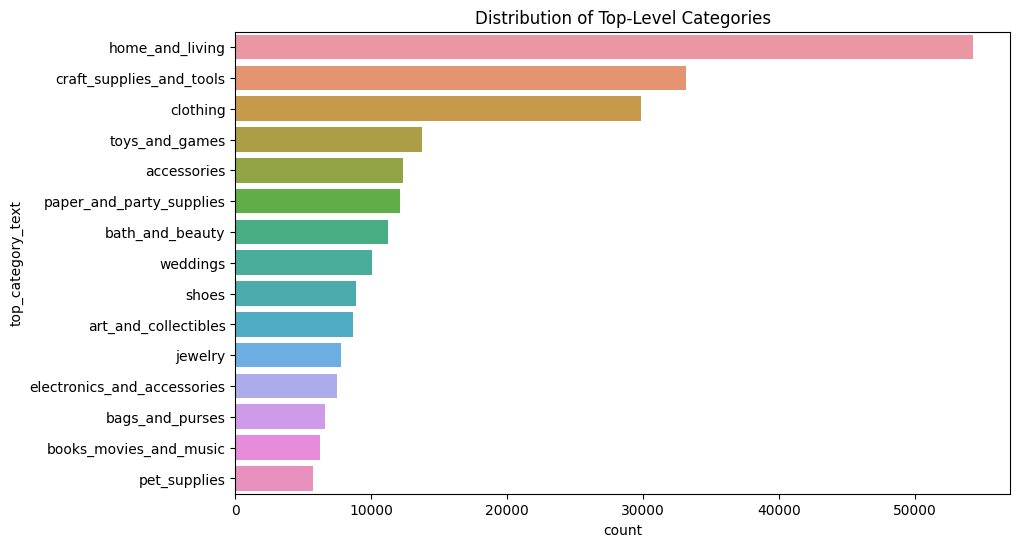

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(y=df_train['top_category_text'], order=df_train['top_category_text'].value_counts().index)
plt.title("Distribution of Top-Level Categories")
plt.show()

In [ ]:
print("Number of Duplicate Rows in bottom_category_text:")
print(df_train['bottom_category_text'].duplicated().sum())

Number of Duplicate Rows in bottom_category_text:
225452


In [ ]:
print("Number of Full Duplicate Rows in the Dataset:")
print(df_train.duplicated().sum())

duplicate_rows = df_train[df_train.duplicated(keep=False)]
print("\nSample of Duplicate Rows:")
print(duplicate_rows.head())

Number of Full Duplicate Rows in the Dataset:
0

Sample of Duplicate Rows:
Empty DataFrame
Columns: [product_id, title, description, tags, type, craft_type, material, occasion, holiday, bottom_category_id, bottom_category_text, top_category_id, top_category_text, primary_color_id, primary_color_text, secondary_color_id, secondary_color_text, title_length, description_length, tags_length]
Index: []


In [ ]:
top_20_categories = df_train['bottom_category_text'].value_counts().index[:20]
print("Top 20 Bottom-Level Categories:")
print(top_20_categories)

Top 20 Bottom-Level Categories:
Index(['home_and_living.kitchen_and_dining.dining_and_serving.cake_stands',
       'art_and_collectibles.drawing_and_illustration.architectural_drawings',
       'home_and_living.kitchen_and_dining.kitchen_decor.refrigerator_magnets',
       'craft_supplies_and_tools.canvas_and_surfaces.paper.collage_sheets',
       'home_and_living.outdoor_and_garden.plants.leaves_and_thorns',
       'home_and_living.outdoor_and_garden.patio_furniture.patio_umbrellas',
       'accessories.scarves_and_wraps.scarves',
       'accessories.hats_and_caps.scrub_caps',
       'bags_and_purses.luggage_and_travel.overnight_bags',
       'home_and_living.home_improvement.lighting_parts.lamp_bases_and_parts',
       'toys_and_games.toys.dolls_and_action_figures.doll_clothing.shorts',
       'toys_and_games.sports_and_outdoor_games.martial_arts_and_boxing.boxing_gloves',
       'home_and_living.kitchen_and_dining.drink_and_barware.barware.ice_buckets',
       'jewelry.earrings.clus

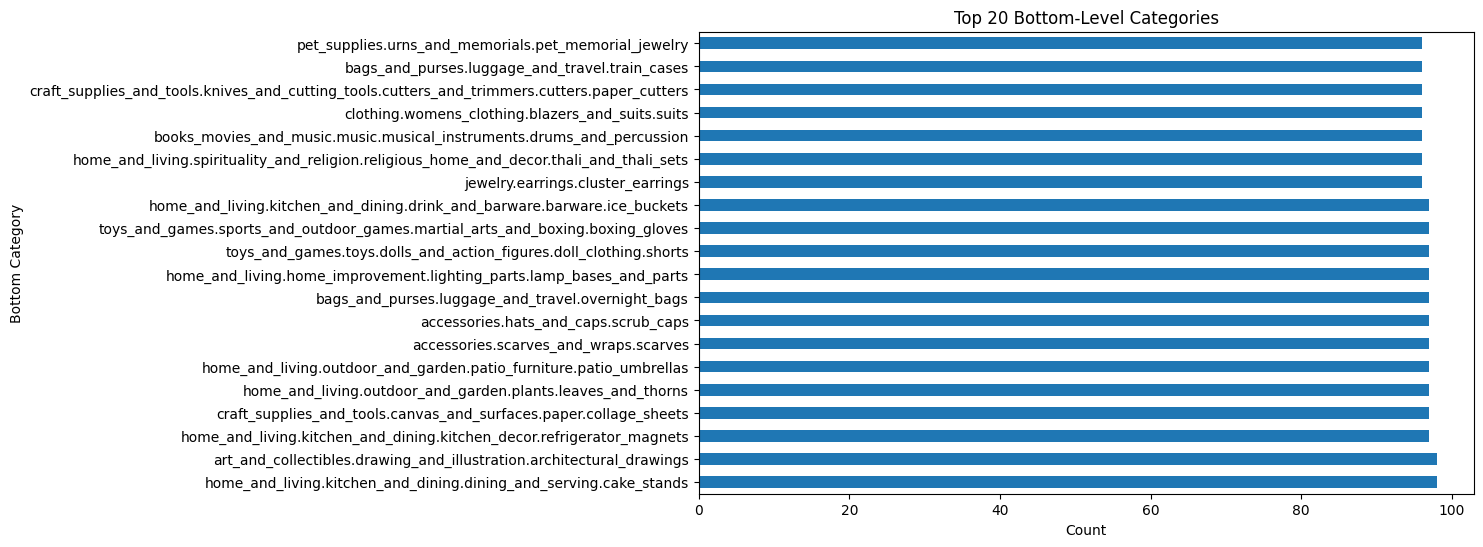

In [ ]:
top_20_categories = df_train['bottom_category_text'].value_counts()[:20]
top_20_categories.plot(kind='barh', figsize=(10, 6), title="Top 20 Bottom-Level Categories")
plt.xlabel("Count")
plt.ylabel("Bottom Category")
plt.show()

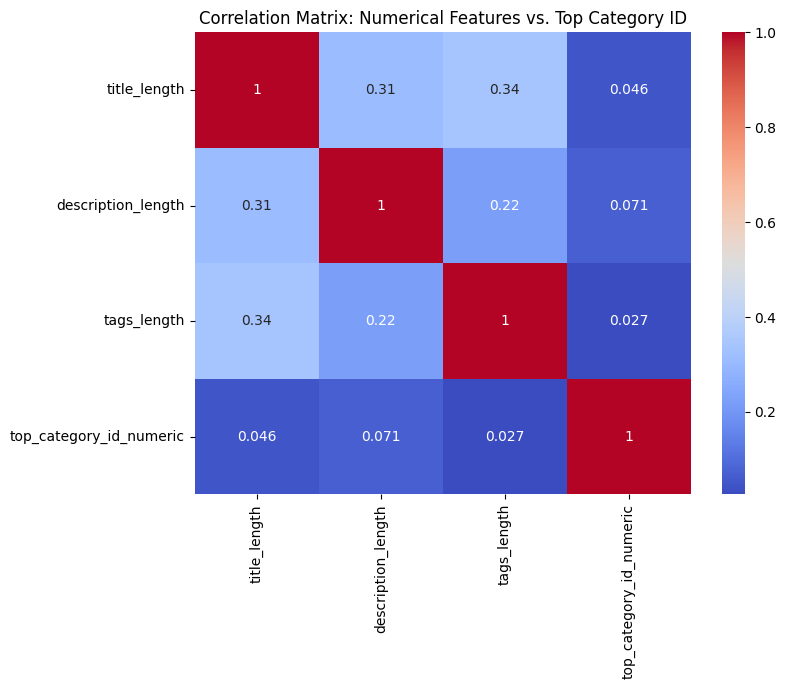

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

numerical_features = ['title_length', 'description_length', 'tags_length']
label_encoder = LabelEncoder()
df_train['top_category_id_numeric'] = label_encoder.fit_transform(df_train['top_category_text'])

correlation_matrix = df_train[numerical_features + ['top_category_id_numeric']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix: Numerical Features vs. Top Category ID")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
available_categorical_features = ['type', 'craft_type', 'material', 'occasion', 'holiday']

encoded_categorical_features = {}
for feature in available_categorical_features:
    label_encoder = LabelEncoder()
    encoded_categorical_features[feature] = label_encoder.fit_transform(df_train[feature].astype(str))

df_encoded = pd.DataFrame(encoded_categorical_features)

In [ ]:
from sklearn.feature_selection import mutual_info_classif

mutual_info_scores = {}
for feature in available_categorical_features:
    mi_score = mutual_info_classif(df_encoded[feature].to_frame(), df_train['top_category_id_numeric'])
    mutual_info_scores[feature] = mi_score[0]

mutual_info_scores_sorted = sorted(mutual_info_scores.items(), key=lambda x: x[1], reverse=True)
print("Mutual Information Scores for Categorical Features:")
for feature, score in mutual_info_scores_sorted:
    print(f"{feature}: {score:.4f}")

Mutual Information Scores for Categorical Features:
craft_type: 0.1643
material: 0.0963
occasion: 0.0678
type: 0.0540
holiday: 0.0192


## Training And Evaluation

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_title = TfidfVectorizer(max_features=1000)
tfidf_description = TfidfVectorizer(max_features=5000)
tfidf_tags = TfidfVectorizer(max_features=1000)

X_title = tfidf_title.fit_transform(df_train['title'])
X_description = tfidf_description.fit_transform(df_train['description'])
X_tags = tfidf_tags.fit_transform(df_train['tags'])

print("Shape of Title Matrix:", X_title.shape)
print("Shape of Description Matrix:", X_description.shape)
print("Shape of Tags Matrix:", X_tags.shape)

Shape of Title Matrix: (228061, 1000)
Shape of Description Matrix: (228061, 5000)
Shape of Tags Matrix: (228061, 1000)


In [ ]:
from scipy.sparse import hstack

X_categorical = df_encoded.values
X_numerical = df_train[['title_length', 'description_length', 'tags_length']].values

X = hstack([X_title, X_description, X_tags, X_categorical, X_numerical])

print("Shape of Combined Feature Matrix:", X.shape)

Shape of Combined Feature Matrix: (228061, 7008)


In [ ]:
y_top = df_train['top_category_id_numeric']
y_bottom = df_train['bottom_category_text']

In [ ]:
from sklearn.model_selection import train_test_split

X_train_top, X_val_top, y_train_top, y_val_top = train_test_split(
    X, y_top, test_size=0.2, random_state=42
)

X_train_bottom, X_val_bottom, y_train_bottom, y_val_bottom = train_test_split(
    X, y_bottom, test_size=0.2, random_state=42
)

print("Top Category - Training Set Shape:", X_train_top.shape)
print("Top Category - Validation Set Shape:", X_val_top.shape)
print("Bottom Category - Training Set Shape:", X_train_bottom.shape)
print("Bottom Category - Validation Set Shape:", X_val_bottom.shape)

Top Category - Training Set Shape: (182448, 7008)
Top Category - Validation Set Shape: (45613, 7008)
Bottom Category - Training Set Shape: (182448, 7008)
Bottom Category - Validation Set Shape: (45613, 7008)


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, f1_score

dtrain_top = xgb.DMatrix(X_train_top, label=y_train_top)
dval_top = xgb.DMatrix(X_val_top, label=y_val_top)

params = {
    'objective': 'multi:softmax',
    'num_class': len(np.unique(y_train_top)),
    'eval_metric': 'mlogloss',
    'random_state': 42,
    'tree_method': 'gpu_hist',
    'max_depth': 8,
    'eta': 0.1
}

bst_top = xgb.train(
    params,
    dtrain_top,
    num_boost_round=100,
    evals=[(dtrain_top, 'train'), (dval_top, 'validation')],
    verbose_eval=10
)



In [ ]:
y_pred_top = bst_top.predict(dval_top)

accuracy_top = accuracy_score(y_val_top, y_pred_top)
f1_top = f1_score(y_val_top, y_pred_top, average='weighted')
bst_top.save_model('top_category_xgboost.model')
print("\nTop Category Accuracy:", accuracy_top)
print("Top Category F1 Score (Weighted):", f1_top)
print("\nClassification Report:")
print(classification_report(y_val_top, y_pred_top))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:729: UserWarning: [06:15:06] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  return func(**kwargs)



Top Category Accuracy: 0.830114221822726
Top Category F1 Score (Weighted): 0.828165547597791

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.68      0.75      2505
           1       0.79      0.51      0.62      1752
           2       0.78      0.82      0.80      1296
           3       0.89      0.76      0.82      2302
           4       0.84      0.77      0.80      1220
           5       0.92      0.94      0.93      6043
           6       0.92      0.87      0.89      6543
           7       0.93      0.75      0.83      1427
           8       0.73      0.91      0.81     10818
           9       0.85      0.86      0.85      1634
          10       0.82      0.77      0.80      2388
          11       0.91      0.87      0.89      1166
          12       0.94      0.95      0.95      1745
          13       0.87      0.70      0.77      2769
          14       0.73      0.65      0.69      2005

    accuracy    

<ipython-input-32-f626885092f3>:7: UserWarning: [06:15:07] WARNING: /workspace/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  bst_top.save_model('top_category_xgboost.model')


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.preprocessing import LabelEncoder

label_encoder_bottom = LabelEncoder()
y_train_bottom_encoded = label_encoder_bottom.fit_transform(y_train_bottom)
y_val_bottom_encoded = label_encoder_bottom.transform(y_val_bottom)

dtrain_bottom = xgb.DMatrix(X_train_bottom, label=y_train_bottom_encoded)
dval_bottom = xgb.DMatrix(X_val_bottom, label=y_val_bottom_encoded)
np.save("label_encoder_classes.npy", label_encoder_bottom.classes_)

In [ ]:
params_bottom = {
    'objective': 'multi:softmax',
    'num_class': len(np.unique(y_train_bottom_encoded)),
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'device': 'cuda',
    'max_depth': 10,
    'eta': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'max_bin': 128
}

bst_bottom = xgb.train(
    params_bottom,
    dtrain_bottom,
    num_boost_round=100,
    evals=[(dtrain_bottom, 'train'), (dval_bottom, 'validation')],
    verbose_eval=10
)

y_pred_bottom = bst_bottom.predict(dval_bottom)
y_pred_bottom_decoded = label_encoder_bottom.inverse_transform(y_pred_bottom.astype(int))

accuracy_bottom = accuracy_score(y_val_bottom, y_pred_bottom_decoded)
f1_bottom = f1_score(y_val_bottom, y_pred_bottom_decoded, average='weighted')

print("\nBottom Category Accuracy:", accuracy_bottom)
print("Bottom Category F1 Score (Weighted):", f1_bottom)
print("\nClassification Report:")
print(classification_report(y_val_bottom, y_pred_bottom_decoded))

[0]	train-mlogloss:6.82950	validation-mlogloss:6.93485
[10]	train-mlogloss:2.62417	validation-mlogloss:3.62231
[20]	train-mlogloss:1.47255	validation-mlogloss:2.94127
[30]	train-mlogloss:0.88914	validation-mlogloss:2.61201
[40]	train-mlogloss:0.55597	validation-mlogloss:2.41256
[50]	train-mlogloss:0.35833	validation-mlogloss:2.28074
[60]	train-mlogloss:0.23894	validation-mlogloss:2.18902


In [ ]:
bst_bottom.save_model("bottom_category_xgboost.model")

# Submission File

In [ ]:

import pandas as pd
import numpy as np
import glob
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

test_folder_path = "/kaggle/input/dtsett/data/2025/test/"
test_files = glob.glob(test_folder_path + "*.parquet.parquet")
if len(test_files) == 0:
    raise ValueError("No .parquet files found in the test folder. Please check the folder path or file extensions.")

df_test = pd.concat([pd.read_parquet(file) for file in test_files])

print("Test Data Shape:", df_test.shape)
print("\nTest Data Preview:")
print(df_test.head())

df_test = df_test.replace(r'^\s*$', np.nan, regex=True)

df_test['title_length'] = df_test['title'].apply(lambda x: len(str(x).split()))
df_test['description_length'] = df_test['description'].apply(lambda x: len(str(x).split()))
df_test['tags_length'] = df_test['tags'].apply(lambda x: len(str(x).split(',')))

df_test['tags'] = df_test['tags'].fillna("No Tags")

df_test['description'] = df_test['description'].apply(lambda x: ' '.join(str(x).split()[:1000]))

textual_columns = ['title', 'description', 'tags']
df_test[textual_columns] = df_test[textual_columns].fillna("")

available_categorical_features = ['type', 'craft_type', 'material', 'occasion', 'holiday']
encoded_categorical_features = {}
for feature in available_categorical_features:
    label_encoder = LabelEncoder()
    encoded_categorical_features[feature] = label_encoder.fit_transform(df_test[feature].astype(str))

df_encoded_test = pd.DataFrame(encoded_categorical_features)

tfidf_title = TfidfVectorizer(max_features=1000)
tfidf_description = TfidfVectorizer(max_features=5000)
tfidf_tags = TfidfVectorizer(max_features=1000)

X_title_test = tfidf_title.fit_transform(df_test['title'])
X_description_test = tfidf_description.fit_transform(df_test['description'])
X_tags_test = tfidf_tags.fit_transform(df_test['tags'])

X_categorical_test = df_encoded_test.values
X_numerical_test = df_test[['title_length', 'description_length', 'tags_length']].values

X_test = hstack([X_title_test, X_description_test, X_tags_test, X_categorical_test, X_numerical_test])

print("Shape of Combined Feature Matrix for Test Data:", X_test.shape)

top_model_path = "/kaggle/input/finalxgb/tensorflow2/default/1/top_category_xgboost.model"
bottom_model_path = "/kaggle/input/bottomxgb/tensorflow2/default/1/bottom_category_xgboost.model.m"

bst_top = xgb.Booster()
bst_top.load_model(top_model_path)

bst_bottom = xgb.Booster()
bst_bottom.load_model(bottom_model_path)

dtest_top = xgb.DMatrix(X_test)
dtest_bottom = xgb.DMatrix(X_test)

y_pred_top = bst_top.predict(dtest_top)

y_pred_bottom = bst_bottom.predict(dtest_bottom)

label_encoder_bottom = LabelEncoder()
label_encoder_bottom.classes_ = np.load("/kaggle/working/label_encoder_classes.npy", allow_pickle=True)
y_pred_bottom_decoded = label_encoder_bottom.inverse_transform(y_pred_bottom.astype(int))

submission = pd.DataFrame({
    "product_id": df_test["product_id"],
    "top_category_id": y_pred_top.astype(int),
    "bottom_category_text": y_pred_bottom_decoded
})

submission.to_parquet("submission.parquet", index=False)

print("Submission file generated successfully!")

Test Data Shape: (25514, 15)

Test Data Preview:
   product_id                                              title  \
0   721040350  blue Flannel herringbone Jon Jon, sizes 3 mont...   
1  1491977070  Vintage 1990s blue denim plaid shortalls 12-18...   
2  1384287640  Children&#39;s corduroy 12 mo Overalls  80&#39...   
3  1641961580  Vintage baby boy girl padded blue cord 1990s 1...   
4   924672770  Vintage utility blue baby shortalls boy  1990s...   

                                         description  \
0  This custom Jon Jon Romper is made from 100% c...   
1  Lovely dungarees/shortalls made in the 1990s.\...   
2  Children&#39;s vintage clothing - Bib overalls...   
3  Lovely cord dungarees made in the 1990s.\nIn v...   
4  Lovely lightweight blue denim style short dung...   

                                                tags      type room  \
0  baby clothes,boys clothes,one piece,boy romper...  physical        
1  denim,striped,baby,1990s,boy,shortalls,9-12 du...  physical 

# Bonus

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

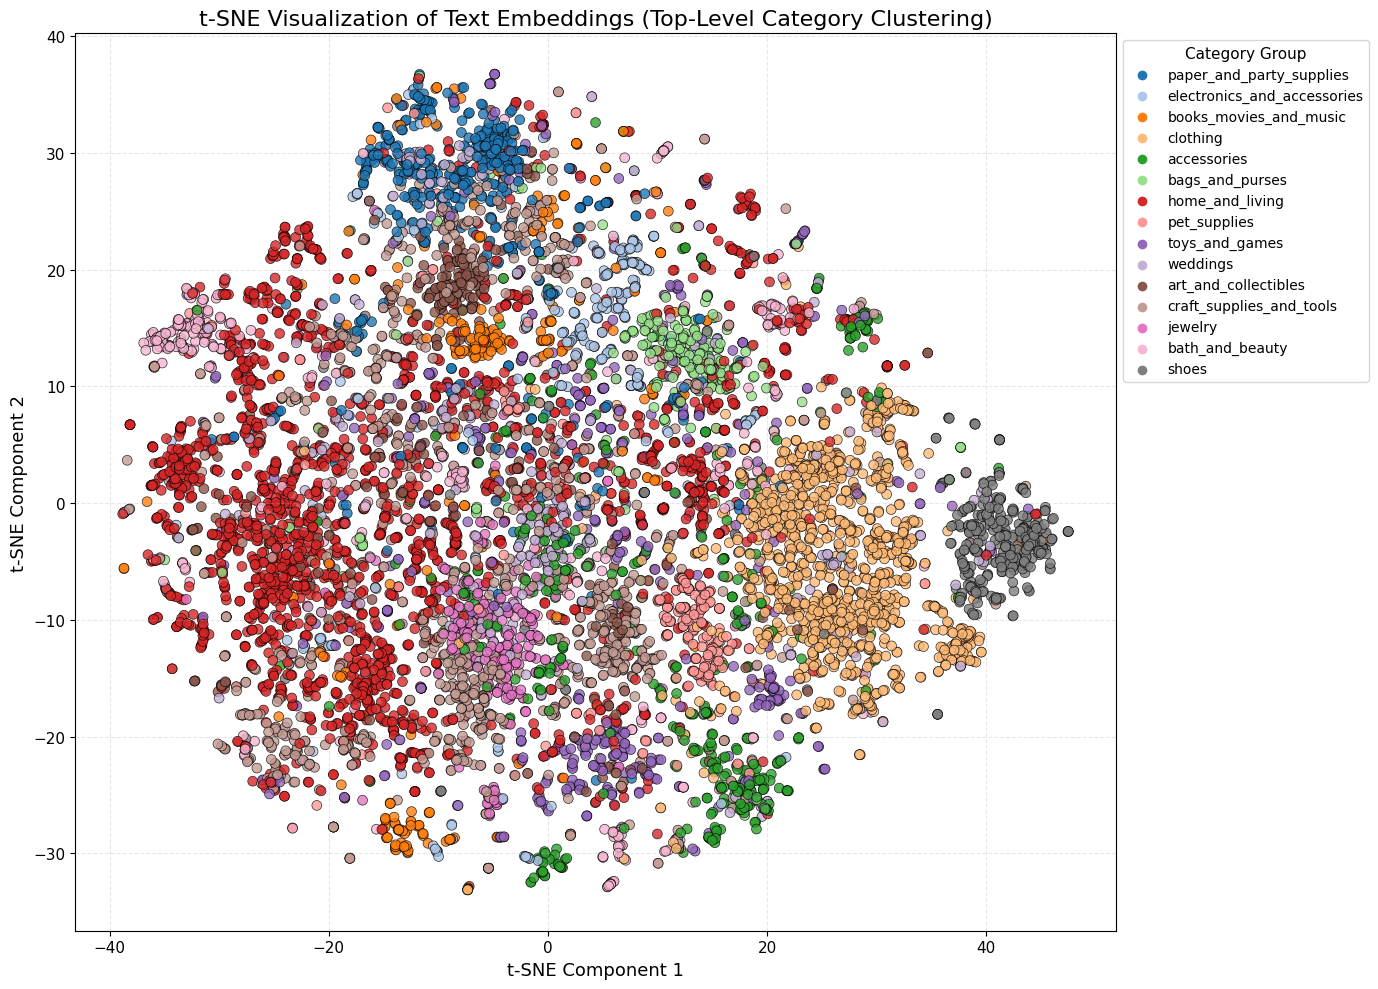

In [ ]:
import pandas as pd
import numpy as np
import re
import html
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
def combine_and_clean(df):
    return (
        df["title"].fillna("") + " " +
        df["description"].fillna("") + " " +
        df["tags"].fillna("")
    )

df_train["combined_text"] = combine_and_clean(df_train)

category_encoder = LabelEncoder()
df_train["top_category_code"] = category_encoder.fit_transform(df_train["top_category_text"])

sample_data = df_train.sample(n=10000, random_state=42).reset_index(drop=True)


embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
text_embeddings = embedding_model.encode(sample_data["combined_text"].tolist(), show_progress_bar=True)

dimension_reducer = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=500)
reduced_dimensions = dimension_reducer.fit_transform(text_embeddings)

plot_data = pd.DataFrame({
    "x_axis": reduced_dimensions[:, 0],
    "y_axis": reduced_dimensions[:, 1],
    "group": sample_data["top_category_text"]
})

plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=plot_data,
    x="x_axis",
    y="y_axis",
    hue="group",
    palette="tab20",
    s=50,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5
)

plt.title("t-SNE Visualization of Text Embeddings (Top-Level Category Clustering)", fontsize=16)
plt.xlabel("t-SNE Component 1", fontsize=13)
plt.ylabel("t-SNE Component 2", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1), title="Category Group", fontsize=10, title_fontsize=11)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

<ipython-input-46-e37bf8d6e397>:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(100, len(x)), random_state=42))


Batches:   0%|          | 0/91 [00:00<?, ?it/s]

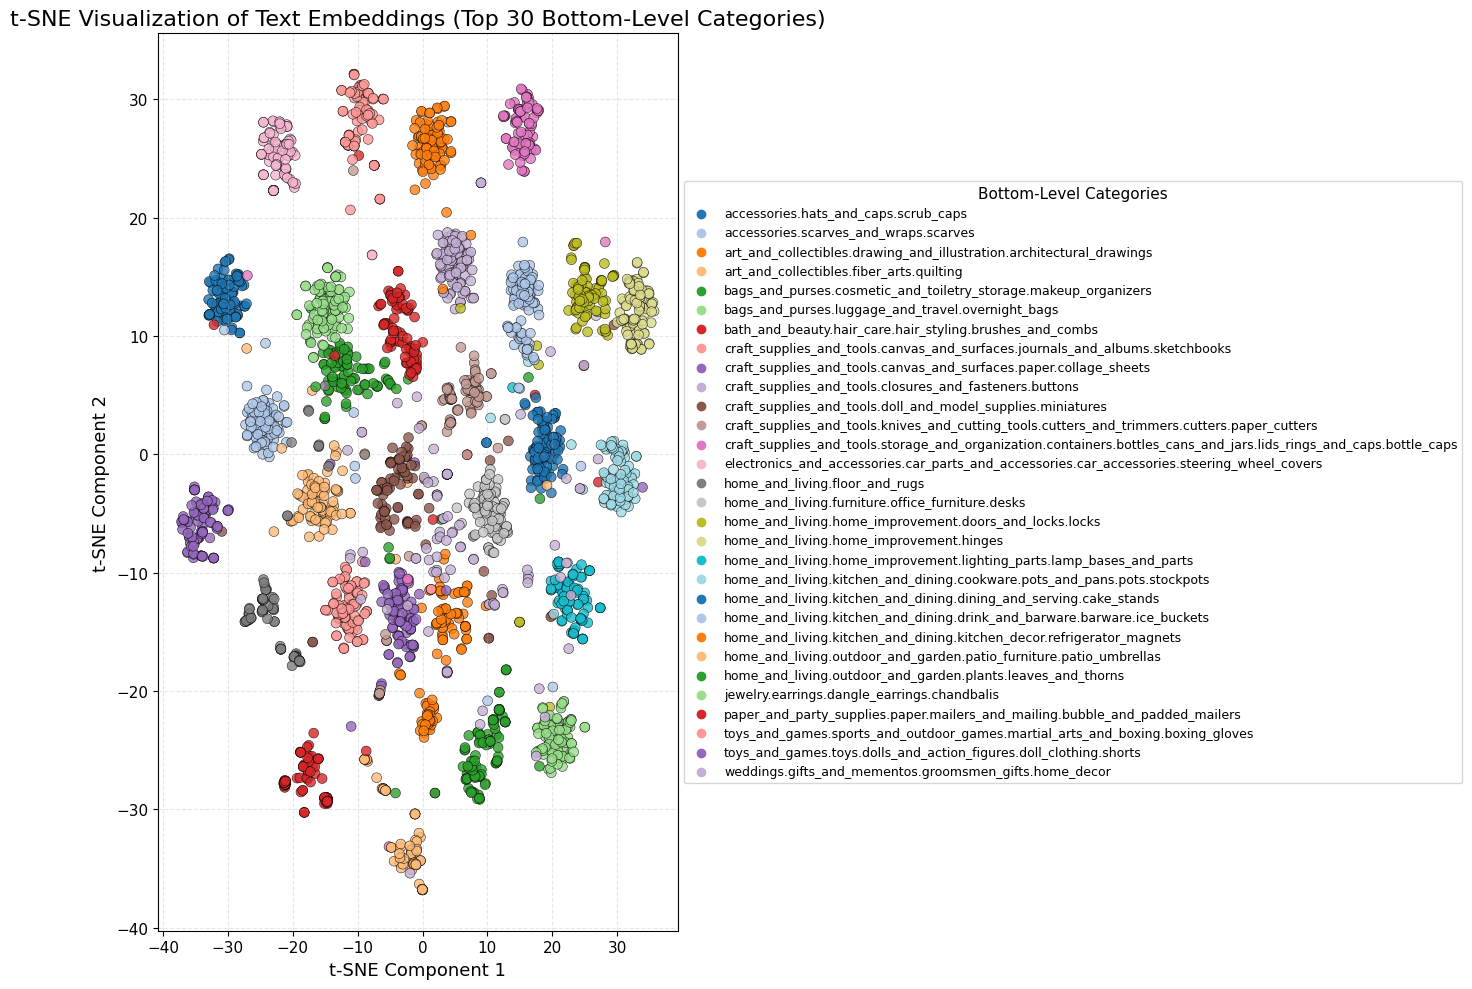

In [ ]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder

top_categories = dataset_train["bottom_category_text"].value_counts().head(30).index
filtered_data = dataset_train[dataset_train["bottom_category_text"].isin(top_categories)]

balanced_data = (
    filtered_data.groupby("bottom_category_text")
    .apply(lambda x: x.sample(n=min(100, len(x)), random_state=42))
    .reset_index(drop=True)
)

def preprocess_text(input_text):
    if pd.isna(input_text): return ""
    input_text = html.unescape(input_text).lower()
    input_text = re.sub(r"[^a-z\s]", "", input_text)
    input_text = re.sub(r"\s+", " ", input_text).strip()
    return input_text

def merge_text_fields(df):
    return (
        df["title"].fillna("") + " " +
        df["description"].fillna("") + " " +
        df["tags"].fillna("")
    ).apply(preprocess_text)

balanced_data["merged_text"] = merge_text_fields(balanced_data)

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
text_embeddings = embedding_model.encode(
    balanced_data["merged_text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)

category_encoder = LabelEncoder()
encoded_labels = category_encoder.fit_transform(balanced_data["bottom_category_text"])

dimension_reducer = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    n_iter=500,
    init='pca'
)
reduced_dimensions = dimension_reducer.fit_transform(text_embeddings)

plot_data = pd.DataFrame({
    "dim1": reduced_dimensions[:, 0],
    "dim2": reduced_dimensions[:, 1],
    "group": category_encoder.inverse_transform(encoded_labels)
})

plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=plot_data,
    x="dim1",
    y="dim2",
    hue="group",
    palette="tab20",
    s=50,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.4,
    legend='full'
)
plt.title("t-SNE Visualization of Text Embeddings (Top 30 Bottom-Level Categories)", fontsize=16)
plt.xlabel("t-SNE Component 1", fontsize=13)
plt.ylabel("t-SNE Component 2", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), title="Bottom-Level Categories", fontsize=9, title_fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

model = SentenceTransformer('all-MiniLM-L6-v2')

df_train['text'] = (
    df_train['title'].fillna("") + " " +
    df_train['description'].fillna("") + " " +
    df_train['tags'].fillna("")
)

print("Generating Sentence-BERT Embeddings...")
pretrained_embeddings = model.encode(
    df_train['text'].tolist(),
    show_progress_bar=True
)

print("Shape of Pre-trained Embeddings:", pretrained_embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating Sentence-BERT Embeddings...


Batches:   0%|          | 0/7127 [00:00<?, ?it/s]

Shape of Pre-trained Embeddings: (228061, 384)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

label_encoder_top = LabelEncoder()
y_top = label_encoder_top.fit_transform(df_train['top_category_text'])

X_train_top, X_val_top, y_train_top, y_val_top = train_test_split(
    pretrained_embeddings, y_top, test_size=0.2, random_state=42
)

print("Top Category - Training Set Shape:", X_train_top.shape)
print("Top Category - Validation Set Shape:", X_val_top.shape)

Top Category - Training Set Shape: (182448, 384)
Top Category - Validation Set Shape: (45613, 384)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

class LogisticRegressionWithProgress(LogisticRegression):
    def fit(self, X, y):
        self._tqdm = tqdm(total=len(X), desc="Training Logistic Regression")
        super().fit(X, y)
        self._tqdm.close()
        return self

    def _fit(self, X, y):
        for i in range(len(X)):
            self._tqdm.update(1)
        return self

clf = LogisticRegressionWithProgress(max_iter=1000, random_state=42)

clf.fit(X_train_top, y_train_top)

y_pred_pretrained = clf.predict(X_val_top)

accuracy_pretrained = accuracy_score(y_val_top, y_pred_pretrained)
f1_pretrained = f1_score(y_val_top, y_pred_pretrained, average='weighted')

print(f"Pre-trained Embeddings - Validation Accuracy: {accuracy_pretrained:.4f}")
print(f"Pre-trained Embeddings - Validation F1 Score: {f1_pretrained:.4f}")

Training Logistic Regression:   0%|          | 0/182448 [00:59<?, ?it/s]

Pre-trained Embeddings - Validation Accuracy: 0.7478
Pre-trained Embeddings - Validation F1 Score: 0.7431


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, classification_report

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

X_train_tensor = torch.tensor(X_train_top, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val_top, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_top, dtype=torch.long).to(device)
y_val_tensor = torch.tensor(y_val_top, dtype=torch.long).to(device)

class FineTunedModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(FineTunedModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 256)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

input_dim = pretrained_embeddings.shape[1]
num_classes = len(label_encoder_top.classes_)
model_top = FineTunedModel(input_dim, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_top.parameters(), lr=0.001)

for epoch in range(10):
    model_top.train()
    optimizer.zero_grad()
    outputs = model_top(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Using device: cpu
Epoch 1, Loss: 2.7025
Epoch 2, Loss: 2.6888
Epoch 3, Loss: 2.6748
Epoch 4, Loss: 2.6581
Epoch 5, Loss: 2.6365
Epoch 6, Loss: 2.6087
Epoch 7, Loss: 2.5738
Epoch 8, Loss: 2.5326
Epoch 9, Loss: 2.4862
Epoch 10, Loss: 2.4388


In [ ]:
model_top.eval()
with torch.no_grad():
    outputs = model_top(X_val_tensor)
    _, y_pred_top = torch.max(outputs, 1)

y_pred_top = y_pred_top.cpu().numpy()
y_val_top = y_val_tensor.cpu().numpy()

accuracy_top = accuracy_score(y_val_top, y_pred_top)
f1_top = f1_score(y_val_top, y_pred_top, average='weighted')
print(f"Top Category - Validation Accuracy: {accuracy_top:.4f}")
print(f"Top Category - Validation F1 Score: {f1_top:.4f}")
print("\nClassification Report:")
print(classification_report(y_val_top, y_pred_top, target_names=label_encoder_top.classes_))

Top Category - Validation Accuracy: 0.2384
Top Category - Validation F1 Score: 0.0918

Classification Report:
                             precision    recall  f1-score   support

                accessories       0.00      0.00      0.00      2460
       art_and_collectibles       0.00      0.00      0.00      1716
            bags_and_purses       0.00      0.00      0.00      1297
            bath_and_beauty       0.00      0.00      0.00      2234
     books_movies_and_music       0.00      0.00      0.00      1290
                   clothing       0.00      0.00      0.00      5826
   craft_supplies_and_tools       0.00      0.00      0.00      6750
electronics_and_accessories       0.00      0.00      0.00      1533
            home_and_living       0.24      1.00      0.39     10874
                    jewelry       0.00      0.00      0.00      1570
   paper_and_party_supplies       0.00      0.00      0.00      2437
               pet_supplies       0.00      0.00      0.00   

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
from sklearn.ensemble import RandomForestClassifier

df_training["text"] = combine_text(df_training)
df_validation["text"] = combine_text(df_validation)


label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(df_training["top_category_text"])
y_val = label_encoder.transform(df_validation["top_category_text"])


def load_glove_embeddings(filepath):
    glove = {}
    with open(filepath, encoding="utf8") as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vec = np.array(parts[1:], dtype=np.float32)
            glove[word] = vec
    return glove

glove_path = r"/Users/sandyajaleshkumar/Desktop/Machine Learning/Assignment/glove.6B/glove.6B.50d.txt"
glove = load_glove_embeddings(glove_path)


def text_to_avg_glove(texts, glove_dict):
    dim = len(next(iter(glove_dict.values())))
    vectors = []
    for text in tqdm(texts, desc="Encoding with GloVe"):
        tokens = text.split()
        vecs = [glove_dict[t] for t in tokens if t in glove_dict]
        if vecs:
            vectors.append(np.mean(vecs, axis=0))
        else:
            vectors.append(np.zeros(dim))
    return np.vstack(vectors)

X_train_glove = text_to_avg_glove(df_training["text"], glove)
X_val_glove = text_to_avg_glove(df_validation["text"], glove)


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_glove, y_train)


y_pred = rf.predict(X_val_glove)
f1 = f1_score(y_val, y_pred, average='weighted')
report = classification_report(y_val, y_pred, target_names=label_encoder.classes_)

print("Classification Report (GloVe + Random Forest):\n")
print(report)
print(f"\nWeighted F1 Score: {f1:.4f}")